In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np


df=pd.read_csv('data_set.csv')
df.head()

#بيحدف اول صف الي فيه الاسئله 
df.drop(index=0, inplace=True)


# هنا بعد ما لقينا ان كل الاعمده بتعامل معامله الاوبجيكت جبنا كل عمود وشوفنه لو كله عباره عن ارقام 
# ومفيهوش استرينج  والشرط اتحقق ف يبنفذ انه بيخلي التايب بتاعه ل int or float
for col in df.columns: 
    if df[col].str.isnumeric().all():
        df[col]=pd.to_numeric(df[col]) 



df.info()

arab_countires='Algeria, Bahrain, Comoros, Djibouti, Egypt, Iraq, Jordan, Kuwait, Lebanon, Libya, Mauritania, Morocco, Oman, Palestine, Qatar, Saudi Arabia, Somalia, Sudan, Syria, Tunisia, United Arab Emirates, Yemen'
arab_countires_list= arab_countires.split(", ")
 
# هنخد البيانات بتاعت الدول العربيه في اوبجكت جديد عشان نتعامل معهاها 
df_arab=df[df['Q3'].isin(arab_countires_list)]



C:\Users\ahmed\AppData\Local\Temp\ipykernel_20420\370662669.py:6: DtypeWarning: Columns (0,18,32,49,56,69,88,100,107,113,139,184,195,201,202,253,266,278,283,285,286,287,288,289,290,291,292,301,322,339,347,355,367) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('data_set.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25973 entries, 1 to 25973
Columns: 369 entries, Time from Start to Finish (seconds) to Q38_B_OTHER
dtypes: float64(30), int64(1), object(338)
memory usage: 73.1+ MB


رسم منحني العمر بنسبه لاعداد الاشخاص من نفس العمر 
------------------------------------------------------

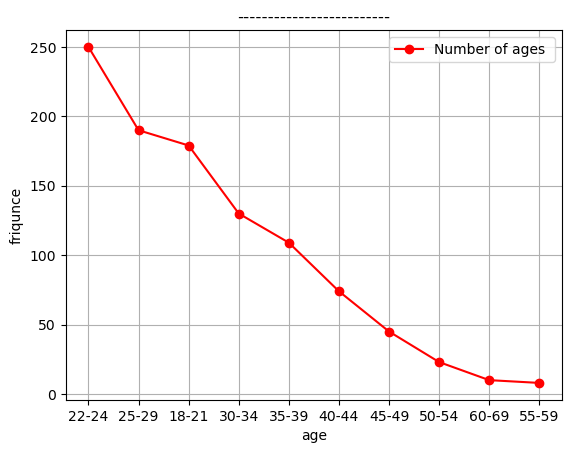

In [34]:
#df_arab['Q3'].unique()
# هنا بيديني عدد الاشخاص اول الكونت بتاعهم 
# و برتبهم تصاعدي  وهحطهم في اوبجكت عشان اعملهم زي السريز واطلع منهم الاندكس والفاليو عشان اعملهم x و y في الرسم 
age_groub= df_arab['Q1'].value_counts().sort_values(ascending=False)


x= age_groub.index
y =age_groub.values

plt.plot(x ,y ,color='r' , marker='o' ,label='Number of ages ' )
plt.xlabel('age')
plt.ylabel('friqunce')
plt.title('-------------------------')

plt.grid()
plt.legend()



رسم country distribution
-------------------

Text(0, 0.5, 'count')

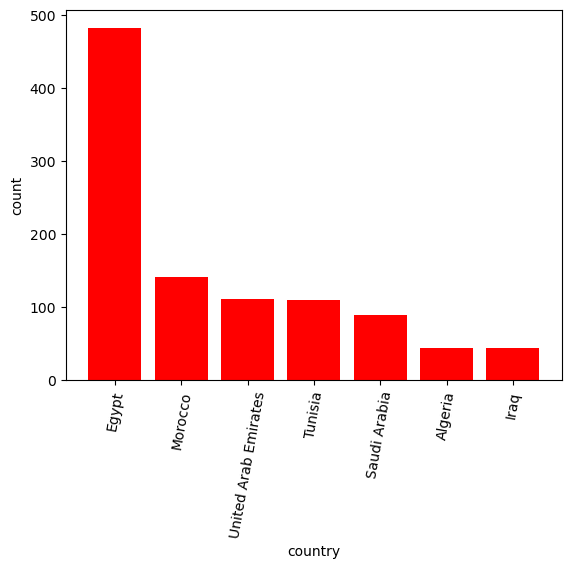

In [ ]:
countries_distribution=df_arab['Q3'].value_counts().sort_values(ascending=False)
x=countries_distribution.index
y=countries_distribution.values

plt.bar(x,y,color='r')
plt.xticks(rotation=80)
plt.xlabel('country')
# plt.ylabel('count')




create pie chart to count of languages
----------------------------------------

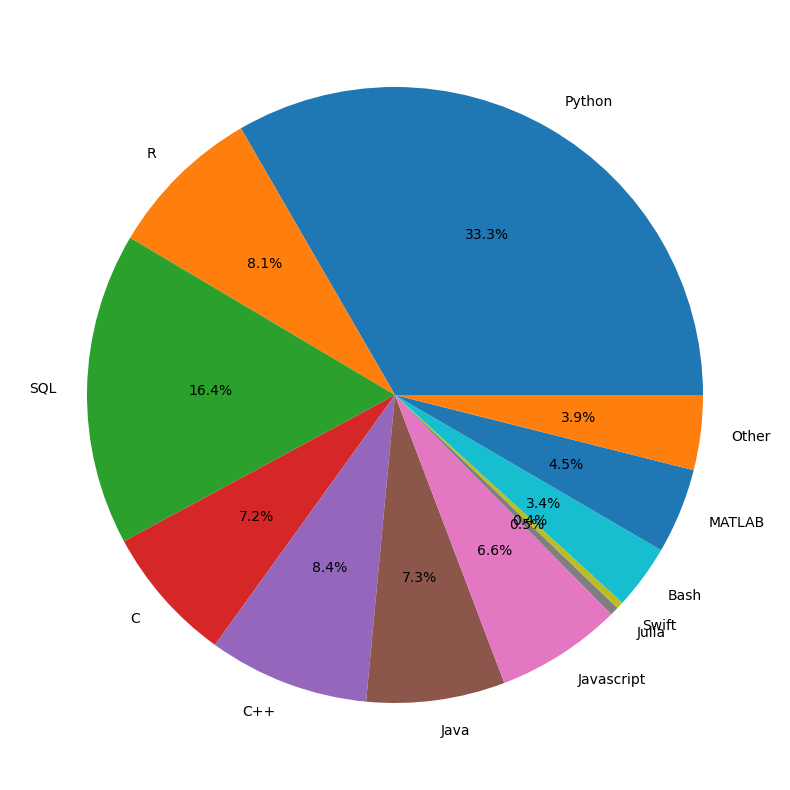

<Figure size 640x480 with 0 Axes>

In [33]:
q7_coulmns=df.columns[df.columns.str.contains('Q7')]

dic_7= dict()

for col in q7_coulmns:
    value = df[col].value_counts()
    if not value.empty:
        key=value.index[0]
        dic_7[key]=value .iloc[0]

dic_7

# هنخزن الديكشنري في series 
q7_series=pd.Series(dic_7)
q7_series

x=q7_series.index
y= q7_series.values
 

plt.figure(figsize=(10,10))
plt.pie(y,
        labels=x ,
          autopct='%1.1f%%')#  % اظهار علامه بلميه 
plt.show()
plt.savefig("user of languages programing")

انشاء صب بلوت هنحط فيها توزيع اللغات 
------------------------------------------

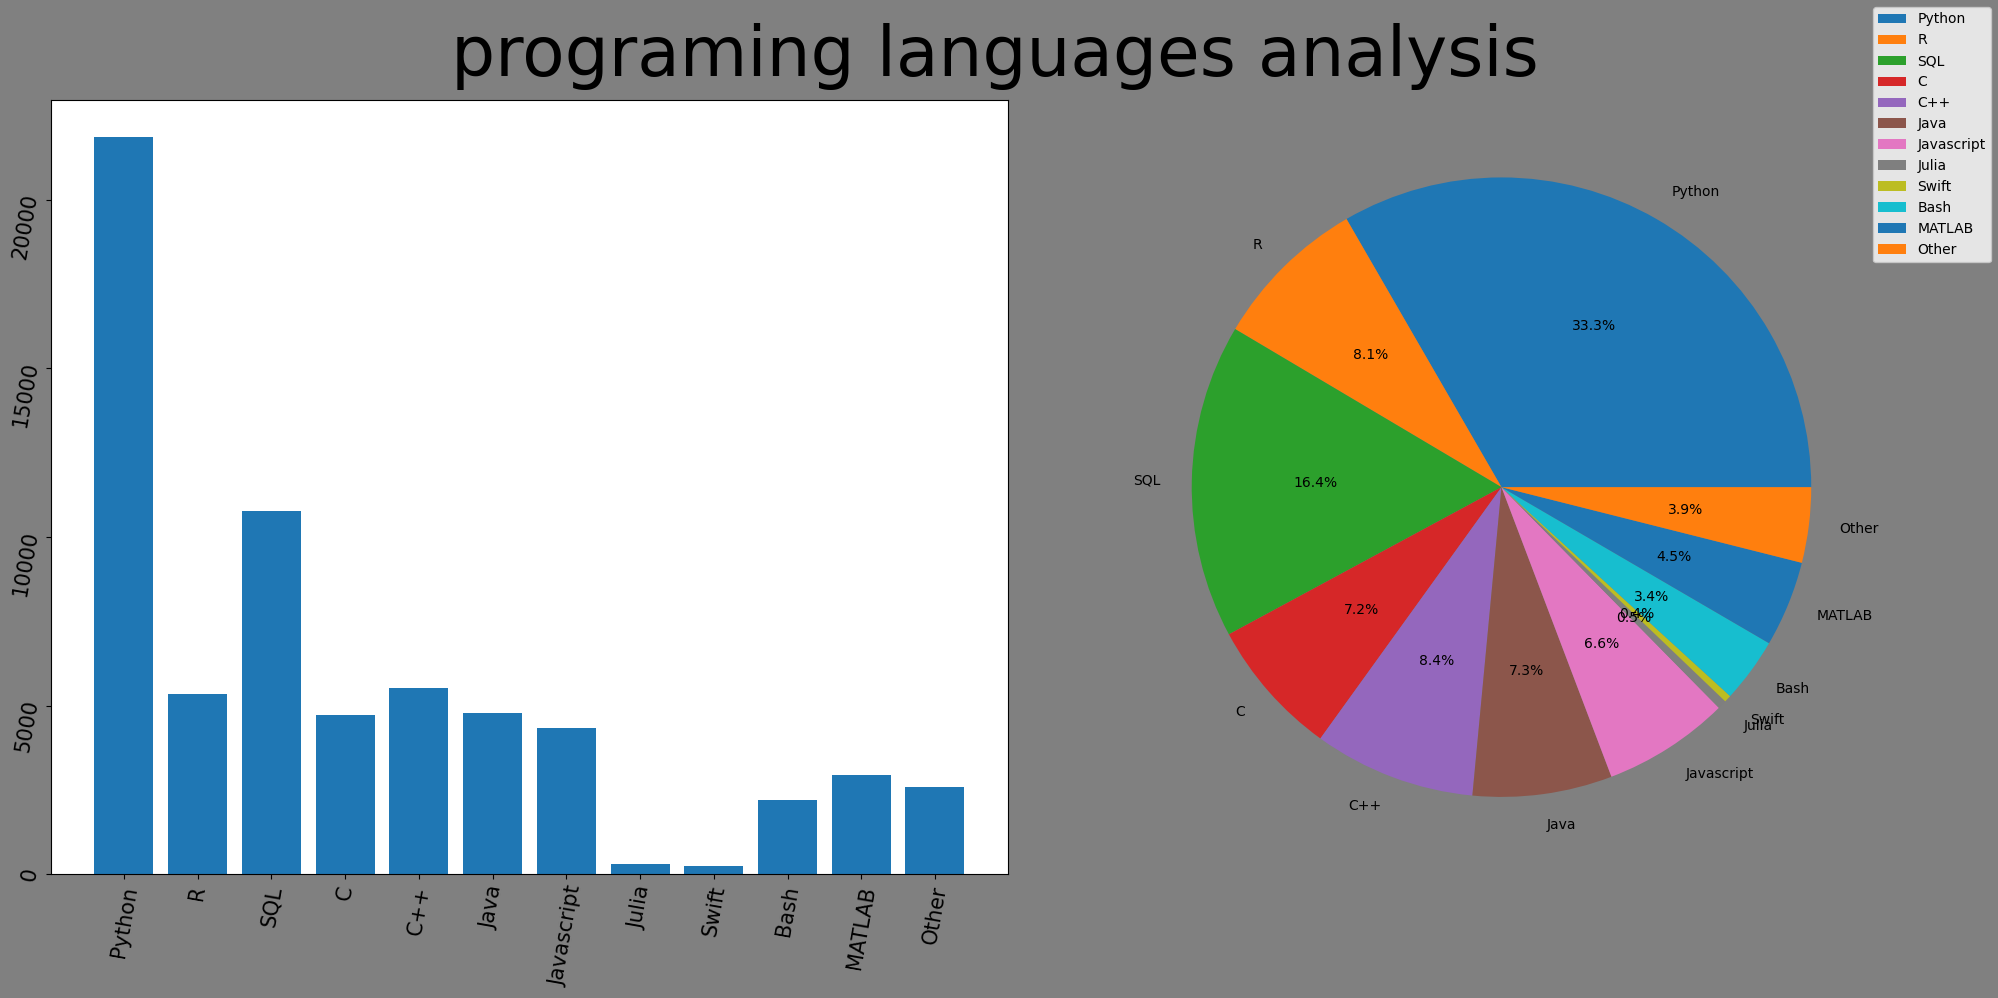

In [71]:
import matplotlib.pyplot as plt
import pandas as pd

q7_coulmns=df.columns[df.columns.str.contains('Q7')]

dic_7= dict()

for col in q7_coulmns:
    value = df[col].value_counts()
    if not value.empty:
        key=value.index[0]
        dic_7[key]=value .iloc[0]

dic_7

# هنخزن الديكشنري في series 
q7_series=pd.Series(dic_7)
q7_series

x=q7_series.index
y= q7_series.values

                                          ### رسم الصب بلوت ####

fig,axes= plt.subplots(1,2,figsize=(20,10))
fig.patch.set_facecolor('grey') # background of subplot
axes[0].bar(x,y ,)     
axes[0].tick_params(labelrotation=80, labelsize=15)  # قلب الكلمات ل زاويه 80 و تكبير الخط  

axes[1].pie(y,labels=x,autopct="%1.1f%%")
fig.suptitle(' programing languages analysis ',fontsize=50)
fig.legend()
plt.tight_layout()

plt.show()
